# Notebook 4: Graph Convolutional Network (GCN)

**Objective:** Train a 2-layer GCN on the Elliptic graph for fraud node classification.

In [1]:
import sys
sys.path.append('../src')

import torch
import matplotlib.pyplot as plt

from graph_builder import load_graph
from models import GCN
from train import train_model
from evaluate import evaluate_model, plot_confusion_matrix, plot_roc_curve, plot_pr_curve, plot_training_history
from utils import set_seed, get_device, save_model

set_seed(42)
device = get_device()
print('Device:', device)
%matplotlib inline

C:\Users\anmol\AppData\Local\Programs\Python\Python310\lib\site-packages\torch_geometric\typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: Could not load this library: C:\Users\anmol\AppData\Local\Programs\Python\Python310\Lib\site-packages\torch_scatter\_version_cpu.pyd
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
C:\Users\anmol\AppData\Local\Programs\Python\Python310\lib\site-packages\torch_geometric\typing.py:124: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: Could not load this library: C:\Users\anmol\AppData\Local\Programs\Python\Python310\Lib\site-packages\torch_sparse\_version_cpu.pyd
  warnings.warn(f"An issue occurred while importing 'torch-sparse'. "


Device: cpu


In [2]:
data = load_graph('../data/processed')
print(data)

Data(x=[46564, 166], edge_index=[2, 36624], y=[46564], train_mask=[46564], val_mask=[46564], test_mask=[46564])


## 1. Model Definition

In [3]:
model = GCN(input_dim=data.num_features, hidden_dim=64, output_dim=2, dropout=0.4)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')

GCN(
  (conv1): GCNConv(166, 64)
  (conv2): GCNConv(64, 2)
)
Total parameters: 10,818


## 2. Training

In [4]:
model, history = train_model(
    model, data,
    epochs=200, lr=0.001, weight_decay=5e-4,
    use_class_weights=True, device=device
)

Epoch  20 | Train Loss: 0.4417 | Val Loss: 0.4192


Epoch  40 | Train Loss: 0.3673 | Val Loss: 0.3777


Epoch  60 | Train Loss: 0.3286 | Val Loss: 0.3505


Epoch  80 | Train Loss: 0.3093 | Val Loss: 0.3343


Epoch 100 | Train Loss: 0.2937 | Val Loss: 0.3232


Epoch 120 | Train Loss: 0.2793 | Val Loss: 0.3158


Epoch 140 | Train Loss: 0.2677 | Val Loss: 0.3104


Epoch 160 | Train Loss: 0.2582 | Val Loss: 0.3059


Epoch 180 | Train Loss: 0.2436 | Val Loss: 0.3027


Epoch 200 | Train Loss: 0.2419 | Val Loss: 0.3003


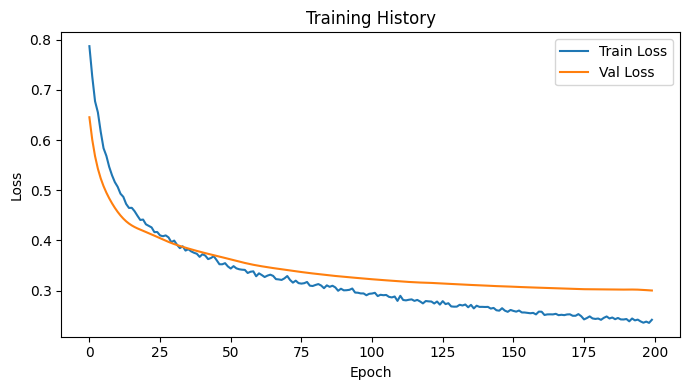

In [5]:
plot_training_history(history, save_path='../results/figures/gcn_training_history.png')

## 3. Evaluation on Test Set

In [6]:
results = evaluate_model(model, data, data.test_mask, device=device)

              precision    recall  f1-score   support

       Licit       0.99      0.91      0.95      8404
     Illicit       0.51      0.90      0.65       909

    accuracy                           0.91      9313
   macro avg       0.75      0.90      0.80      9313
weighted avg       0.94      0.91      0.92      9313

ROC-AUC : 0.9648
PR-AUC  : 0.8098


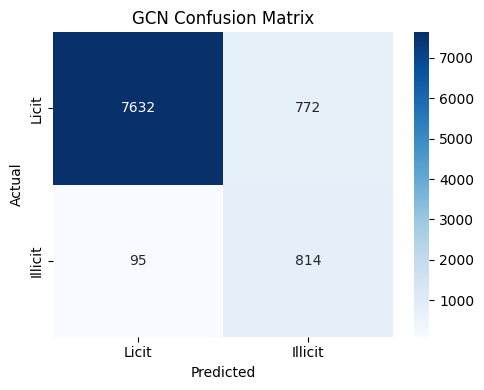

In [7]:
plot_confusion_matrix(results['y_true'], results['y_pred'],
                      title='GCN Confusion Matrix',
                      save_path='../results/confusion_matrices/gcn_cm.png')

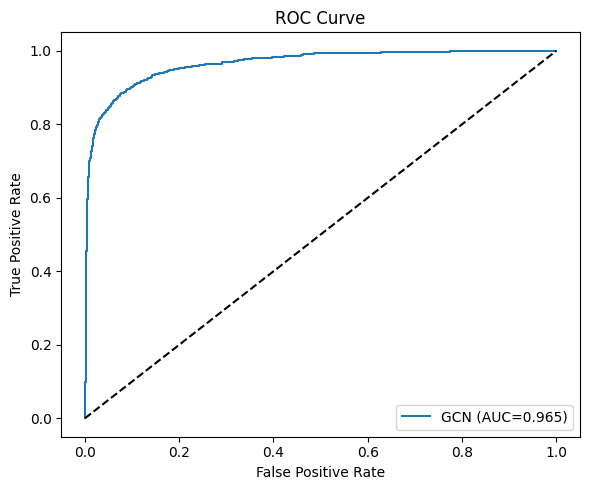

In [8]:
plot_roc_curve(results['y_true'], results['y_prob'], label='GCN',
               save_path='../results/figures/gcn_roc.png')

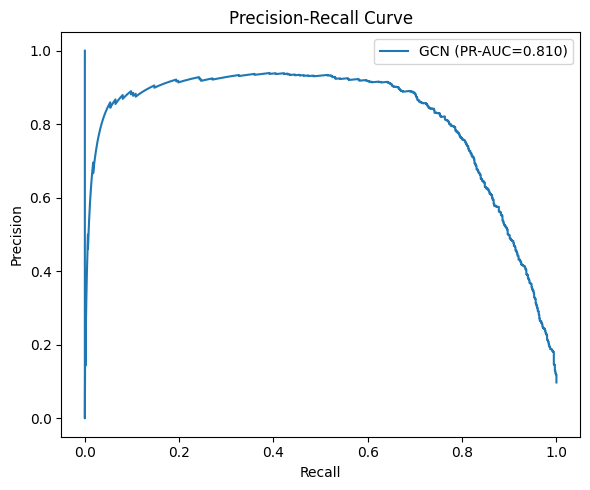

In [9]:
plot_pr_curve(results['y_true'], results['y_prob'], label='GCN',
              save_path='../results/figures/gcn_pr.png')

## 4. Save Model

In [10]:
save_model(model, '../models/gcn_model.pt')

Model saved to ../models/gcn_model.pt
